In [1]:
import sys
from pathlib import Path
sys.path.append("..")

import argparse
import logging
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import umap.umap_ as umap

from styles.colors import get_colors
from src.core.data_utils import load_annotation, load_data
from src.core.logging_utils import setup_logging
from sklearn.metrics.pairwise import pairwise_distances

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.metrics import mutual_info_score, normalized_mutual_info_score

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from scipy import stats
from statsmodels.stats.multitest import multipletests

c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

In [2]:
def plot_umap(X, cluster_labels, metric="cosine", random_state=42):
    """Plot UMAP embedding colored by cluster labels."""
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric=metric, random_state=random_state)
    embedding = reducer.fit_transform(X)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
    plt.title("UMAP Projection of Clusters")
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(True, alpha=0.3)
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.show()

def bar_plot_cluster_selection_probabilities(X, cluster_labels, proteins):
    """Bar plot of mean selection probabilities for each protein in each cluster."""
    unique_clusters = np.unique(cluster_labels)
    mean_selection_probs = {cluster: np.mean(X[cluster_labels == cluster], axis=0) for cluster in unique_clusters}

    x = np.arange(len(proteins))
    width = 1 / (len(unique_clusters)+1)

    plt.figure(figsize=(12, 6))
    for i, cluster in enumerate(unique_clusters):
        plt.bar(x + i*width - width/2 * len(unique_clusters), mean_selection_probs[cluster], width, label=f'Cluster {cluster+1 if cluster >= 0 else "Noise"}', alpha=0.7)
    
    plt.xlabel('Proteins')
    plt.ylabel('Mean Selection Probability')
    plt.title('Mean Selection Probability of Proteins in Each Cluster')
    plt.xticks(x, proteins, rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [158]:
def run_ttest(X, y, p_threshold=0.05, proteins=None):
    """Run t-tests for each protein and return the indices of selected proteins."""
    _, p_vals = stats.ttest_ind(
        X[y == 1], 
        X[y == 0], 
        axis=0, 
        equal_var=False, 
        nan_policy='omit'
    )

    # Adjust for multiple testing
    #reject, adj_p_vals, _, _ = multipletests(p_vals, alpha=p_threshold, method='fdr_bh')
    reject = p_vals < p_threshold
    adj_p_vals = None

    if proteins is not None:
        sig_proteins = [prot for prot, is_sig in zip(proteins, reject) if is_sig]
        return reject, adj_p_vals, sig_proteins

    return reject, adj_p_vals

def run_lasso(X, y, alpha = 1.0, l1_ratio=1.0):
    """Run Lasso regression and return the indices of selected proteins."""
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    model = LogisticRegressionCV(
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[l1_ratio],
            cv=5,
            scoring="roc_auc",
            max_iter=5000,
            n_jobs=-1,
        )

    model.fit(X, y)

    # Extract coefficients
    coef = model.coef_.ravel()

    # Record selection (non-zero coefficients)
    return (coef != 0).astype(int)


In [6]:
def seq_to_probeid(name: str) -> str:
    s = str(name)
    s = re.sub(r"^seq\.", "", s)
    s = re.sub(r"^seq", "", s)
    # Replace first occurrence of digits.digits with digits-digits
    s = re.sub(r"([0-9]+)\.([0-9]+)", r"\1-\2", s)
    return s

## Load data

In [4]:
df = pd.read_csv("../data/processed/filtered_data.csv")

proteins = [c for c in df.columns if c.startswith("seq.")]
X = df[proteins].values
y = df["ards"].values

C:\Users\Love\AppData\Local\Temp\ipykernel_26752\1804087720.py:1: DtypeWarning: Columns (10818,10820) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/filtered_data.csv")


In [5]:
annot_df = pd.read_csv("../data/processed/somalogic_annotation.csv")
annot_df.head()

,PROBEID,SYMBOL,UNIPROT,ENTREZID,GENENAME
0,10000-28,CRYBB2,A0A0H3W5U0,1415.0,crystallin beta B2
1,10001-7,RAF1,A0A0S2Z559,5894.0,"Raf-1 proto-oncogene, serine/threonine kinase"
2,10003-15,ZNF41,P51814,7592.0,zinc finger protein 41
3,10006-25,ELK1,B2R7H4,2002.0,ETS transcription factor ELK1
4,10008-43,GUCA1A,B2R9P6,2978.0,guanylate cyclase activator 1A


## Initial t-test for comparison

In [16]:
_, _, sig_proteins = run_ttest(X, y, p_threshold=0.05, proteins=proteins)
probeid = [seq_to_probeid(prot) for prot in sig_proteins]
protein_sig_df = pd.DataFrame({
    "PROBEID": probeid,
    "protein": sig_proteins
})
protein_sig_df = protein_sig_df.merge(annot_df, on="PROBEID", how="left")
#protein_sig_df.head()
for row in protein_sig_df.itertuples():
    print(f"{row.SYMBOL}")

STAT1
GOLM1
USH1C
HAO1
ALDH5A1
BPHL
ACADL
BLOC1S2
ACY3
RGN
GYG2
ACSS2
SDHAF2
MAFF
NOTCH2NLB
HSF4
PABPC1
RTF1
COX5B
GOLM1


# Stability selection

## Protein selection

In [22]:
from sklearn.linear_model import Lasso, lasso_path

In [67]:
model = Lasso(alpha=0.01)
model.fit(X, y)
sum(model.coef_ != 0)

np.int64(41)

In [170]:
n_samples, n_features = X.shape
n_iterations = 100

#lambdas = np.concatenate((np.arange(0.001, 0.01, 0.001), np.arange(0.01, 0.055, 0.005)))
lambdas = np.array([0.01, 0.005, 0.001, 0.0005])

selection_matrix_lambda = {lambda_val: np.zeros((n_iterations, n_features)) for lambda_val in lambdas}
coef_path_lambda = {lambda_val: np.zeros((n_features, n_iterations)) for lambda_val in lambdas}

for b in range(n_iterations):
    if (b+1) % 10 == 0:
        print(f"Iteration {b+1}/{n_iterations}")
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.5, random_state=b)
    
    for lambda_val in lambdas:
        selection_matrix_lambda[lambda_val][b, :] = run_ttest(X_train, y_train, p_threshold=lambda_val)[0]
    
    #for lambda_val in lambdas:
    #    #scaler = StandardScaler()
    #    #X_train_scaled = scaler.fit_transform(X_train)
    #    model = Lasso(alpha=lambda_val, max_iter=5000, tol=1e-2, random_state=b)
    #    model.fit(X_train, y_train)
    #    selection_matrix_lambda[lambda_val][b, :] = (model.coef_ != 0).astype(int)
    #    coef_path_lambda[lambda_val][:, b] = model.coef_

Iteration 10/100
Iteration 20/100
Iteration 30/100
Iteration 40/100
Iteration 50/100
Iteration 60/100
Iteration 70/100
Iteration 80/100
Iteration 90/100
Iteration 100/100


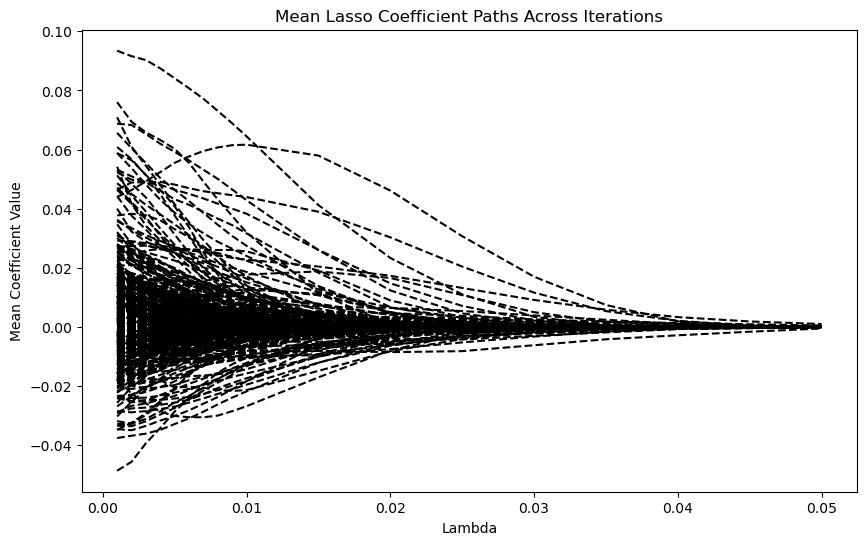

In [144]:
# plot mean coefficient paths (mean across iterations)
coef_path = np.zeros((n_features, len(lambdas)))
for i, lambda_val in enumerate(lambdas):
    coef_path[:, i] = np.mean(coef_path_lambda[lambda_val], axis=1)

plt.figure(figsize=(10, 6))
for i in range(coef_path.shape[0]):
    plt.plot(lambdas, coef_path[i], "k--", label=f'Protein {i+1}')
plt.xlabel('Lambda')
plt.ylabel('Mean Coefficient Value')
plt.title('Mean Lasso Coefficient Paths Across Iterations')
plt.show()

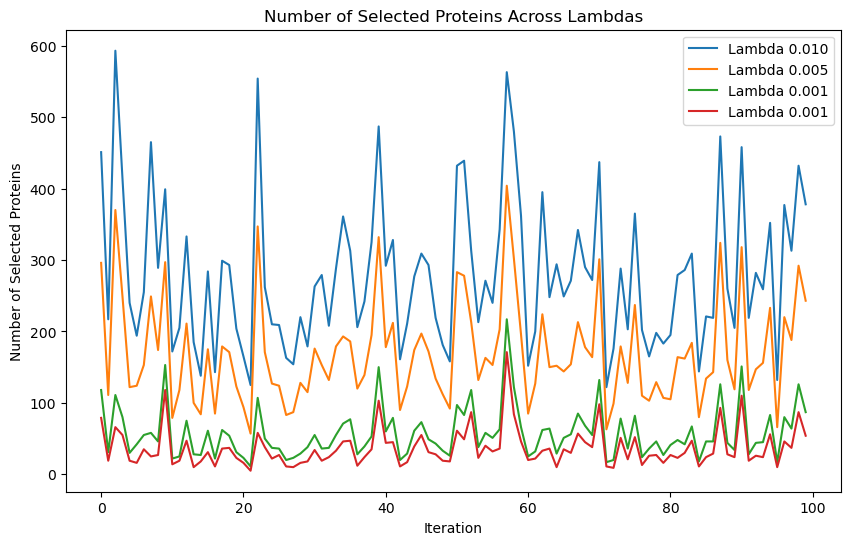

In [171]:
# Compute nbr selected feature for each iteration and lambda
n_selected_features = {lambda_val: np.sum(selection_matrix_lambda[lambda_val], axis=1) for lambda_val in lambdas}
# plot number of selected features across lambdas
plt.figure(figsize=(10, 6))
for lambda_val in lambdas:
    plt.plot(n_selected_features[lambda_val], label=f'Lambda {lambda_val:.3f}')
plt.xlabel('Iteration')
plt.ylabel('Number of Selected Proteins')
plt.title('Number of Selected Proteins Across Lambdas')
plt.legend()
plt.show()

In [172]:
# Calculate selection probabilities
selection_probabilities = {lambda_val: np.mean(selection_matrix_lambda[lambda_val], axis=0) for lambda_val in lambdas}

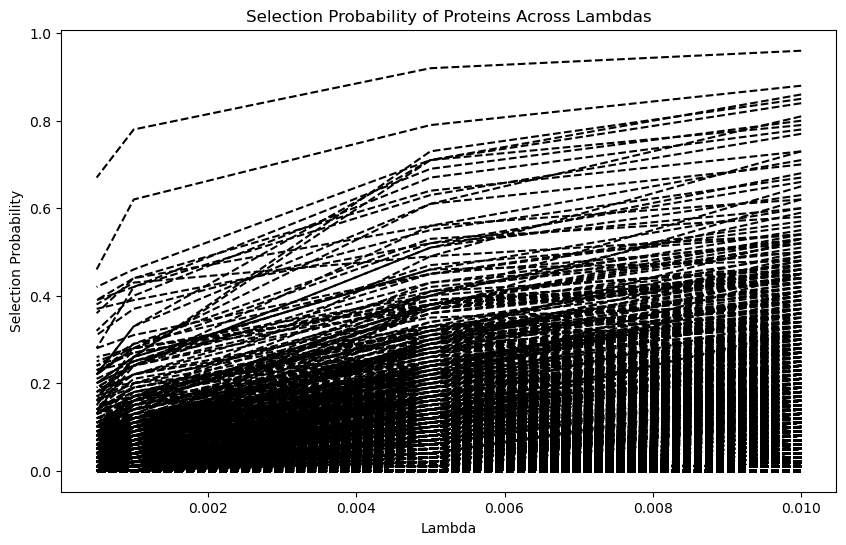

In [173]:
# plot selection probabilites against lambdas
plt.figure(figsize=(10, 6))
for i in range(n_features):
    plt.plot(lambdas, [selection_probabilities[lambda_val][i] for lambda_val in lambdas], "k--", label=f'Protein {i+1}')
plt.xlabel('Lambda')
plt.ylabel('Selection Probability')
plt.title('Selection Probability of Proteins Across Lambdas')
plt.show()

In [174]:
max_selection_prob = np.zeros(n_features)
for k in range(n_features):
    max_selection_prob[k] = max(selection_probabilities[lam][k] for lam in lambdas)

In [175]:
# Choose q_lambda: number of variables entering across the path
# Estimate from your subsamples
q_lambda = np.mean([
    len(np.unique(np.where(
        np.column_stack([selection_matrix_lambda[lam][b, :] for lam in lambdas])
    )[0]))
    for b in range(n_iterations)
])

# For a given pi_thr, the expected false discoveries:
# E(V) <= q_lambda^2 / (p * (2*pi_thr - 1))
pi_thr = 0.75
expected_false = q_lambda**2 / (n_features * (2 * pi_thr - 1))
print(f"q_lambda: {q_lambda:.1f}")
print(f"E(V) <= {expected_false:.2f} at pi_thr={pi_thr}")

q_lambda: 279.2
E(V) <= 14.46 at pi_thr=0.75


In [176]:
stable_set = np.where(max_selection_prob >= pi_thr)[0]

In [177]:
stable_proteins = [proteins[i] for i in stable_set]
probeid = [seq_to_probeid(prot) for prot in stable_proteins]
protein_sig_df = pd.DataFrame({
    "PROBEID": probeid,
    "protein": stable_proteins
})
protein_sig_df = protein_sig_df.merge(annot_df, on="PROBEID", how="left")
#protein_sig_df.head()
for row in protein_sig_df.itertuples():
    print(f"{row.SYMBOL}")

GOLM1
USH1C
ALDH5A1
BLOC1S2
GYG2
SDHAF2
HSF4
RTF1
COX5B
GOLM1


In [178]:
# Check how many variables enter at each lambda
for lam in lambdas:
    avg_selected = np.mean([selection_matrix_lambda[lam][b, :].sum() for b in range(n_iterations)])
    print(f"lambda={lam:.4f}: avg selected = {avg_selected:.1f}")

lambda=0.0100: avg selected = 279.2
lambda=0.0050: avg selected = 170.2
lambda=0.0010: avg selected = 57.5
lambda=0.0005: avg selected = 36.9


In [153]:
# Need: q_lambda^2 / (p * (2*0.75 - 1)) <= 1
# q_lambda <= sqrt(p * 0.5)
pi_thr_desired = 0.6
q_max = np.sqrt(n_features * (2*pi_thr_desired - 1))
print(f"Need q_lambda <= {q_max:.1f}")

Need q_lambda <= 46.4


In [112]:
desired_EV = 10  # want at most 1 false discovery in expectation
# Solve: desired_EV = q_lambda^2 / (p * (2*pi_thr - 1))
# pi_thr = 0.5 * (q_lambda^2 / (p * desired_EV) + 1)
pi_thr_derived = 0.5 * (q_lambda**2 / (n_features * desired_EV) + 1)
print(f"Required pi_thr for E(V)<=1: {pi_thr_derived:.3f}")

Required pi_thr for E(V)<=1: 0.766


In [6]:
n_samples, n_features = X.shape
n_iterations = 500

selection_matrix = np.zeros((n_iterations*2, n_features), dtype=int)

rng = np.random.default_rng(seed=42)

for b in range(n_iterations):
    if (b+1) % 100 == 0:
        print(f"Iteration {b+1}/{n_iterations}")
    # Bootstrap sampling or subsampling with replacement
    #boot_idx = np.random.choice(n_samples, size=n_samples, replace=True)

    ## subsample without replacement
    X1, X2, y1, y2 = train_test_split(X, y, test_size=0.5, random_state=rng.integers(1e9), stratify=y)
            
    # Protein selection 
    selection_matrix[2*b]     = run_ttest(X1, y1)[0]
    selection_matrix[2*b + 1] = run_ttest(X2, y2)[0]

# Selection frequency
selection_freq = selection_matrix.mean(axis=0)

Iteration 100/500
Iteration 200/500
Iteration 300/500
Iteration 400/500
Iteration 500/500


# OLD 

Number of iterations with at least 1 significant proteins: 693 out of 1000
Number of iterations with at least 5 significant proteins: 412 out of 1000
Number of iterations with at least 10 significant proteins: 287 out of 1000


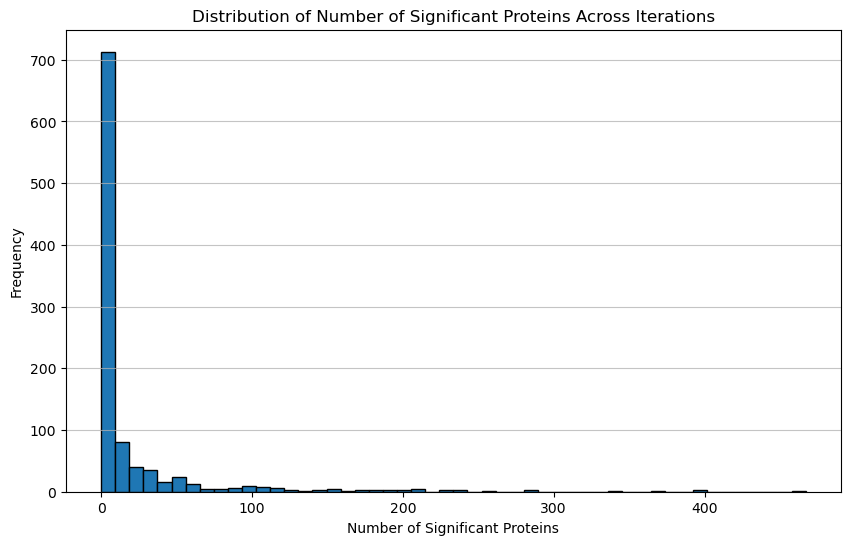

In [7]:
#number of proteins selected in each iteration
n_selected_proteins = selection_matrix.sum(axis=1)

print(f"Number of iterations with at least 1 significant proteins: {np.sum(n_selected_proteins >= 1)} out of {len(n_selected_proteins)}")
print(f"Number of iterations with at least 5 significant proteins: {np.sum(n_selected_proteins >= 5)} out of {len(n_selected_proteins)}")
print(f"Number of iterations with at least 10 significant proteins: {np.sum(n_selected_proteins >= 10)} out of {len(n_selected_proteins)}")


plt.figure(figsize=(10, 6))
plt.hist(n_selected_proteins, bins=50, edgecolor='black')
plt.title("Distribution of Number of Significant Proteins Across Iterations")
plt.xlabel("Number of Significant Proteins")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [8]:
proteins_to_keep = [prot for i, prot in enumerate(proteins) if selection_freq[i] > 0.05]
print(f"Number of proteins to keep: {len(proteins_to_keep)}")

idx_keep = [proteins.index(prot) for prot in proteins_to_keep]

# Matrix for clustering
Z = selection_matrix[:, idx_keep]

Number of proteins to keep: 77


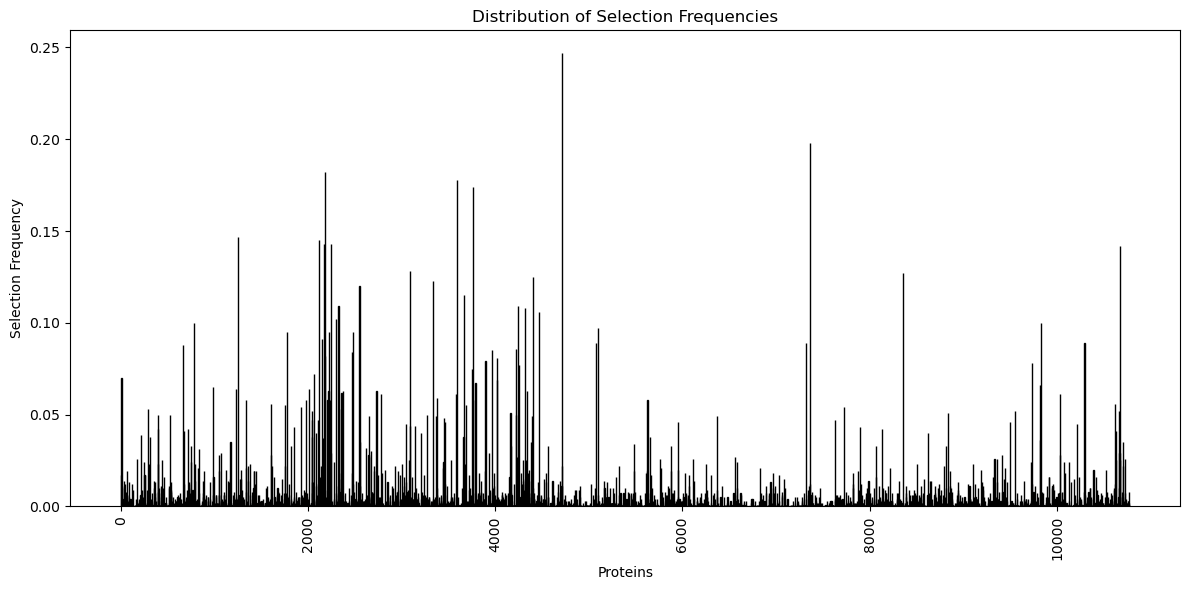

In [9]:
# plot selection frequencies
plt.figure(figsize=(12, 6))
x = np.arange(len(proteins))
plt.bar(x, selection_freq, color='skyblue', edgecolor='black')
plt.xlabel("Proteins")
plt.ylabel("Selection Frequency")
plt.title("Distribution of Selection Frequencies")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

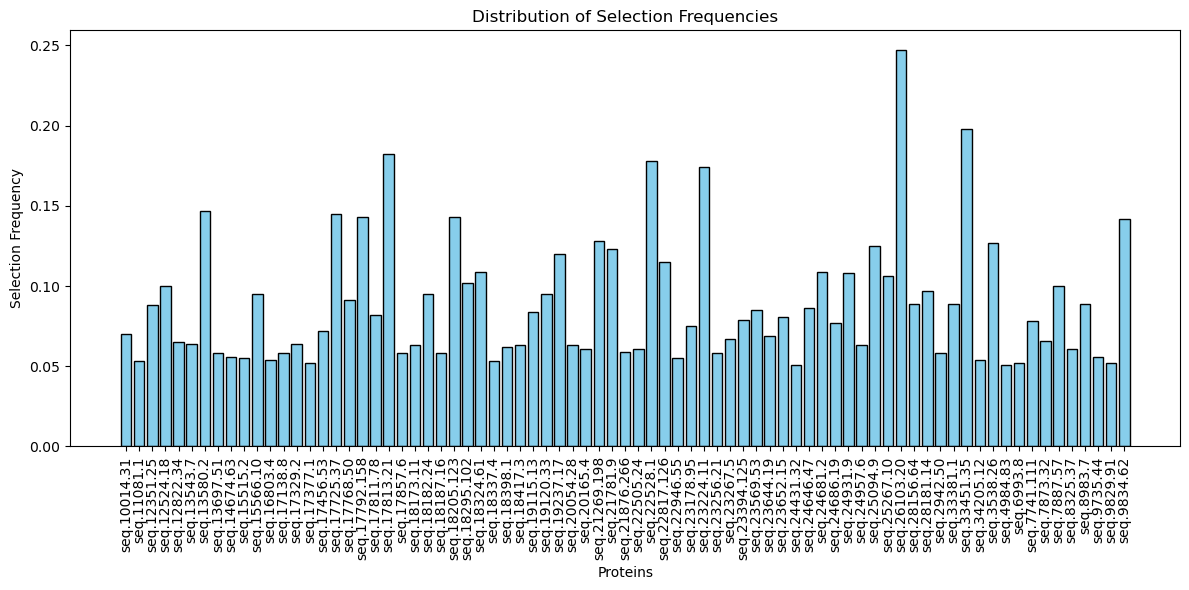

In [10]:
plt.figure(figsize=(12, 6))
x = np.arange(len(proteins_to_keep))
plt.bar(x, selection_freq[idx_keep], color='skyblue', edgecolor='black')
plt.xticks(x, proteins_to_keep, rotation=90)
plt.xlabel("Proteins")
plt.ylabel("Selection Frequency")
plt.title("Distribution of Selection Frequencies")
plt.tight_layout()
plt.show()

## Co-selection correlation 

In [45]:
def compute_coselect_corr(Z):
    pi = Z.mean(axis=0)

    C = (Z.T @ Z) / Z.shape[0] 

    pi_outer = np.outer(pi, pi)
    numerator = C - pi_outer
    denominator = np.sqrt(np.outer(pi * (1 - pi), pi * (1 - pi)))

    denominator[denominator == 0] = 1e-10
    r = numerator / denominator
    np.fill_diagonal(r, 0)  # no self-loops
    return r

def compute_jaccard_index(Z):
    intersection = Z.T @ Z
    row_sums = Z.sum(axis=0)
    union = row_sums[:, None] + row_sums[None, :] - intersection

    union[union == 0] = 1e-10
    jaccard_index = intersection / union
    np.fill_diagonal(jaccard_index, 0)  # no self-loops
    return jaccard_index

In [46]:
pi = Z.mean(axis=0)
r = compute_jaccard_index(Z)

## Threshold weak edges - based on permutation

In [48]:
n_perms = 1000
null_max = np.zeros(n_perms)  # track max r per permutation

for p_idx in range(n_perms):
    Z_perm = Z.copy()
    for col in range(Z_perm.shape[1]):
        rng.shuffle(Z_perm[:, col])
    
    #r_perm = compute_coselect_corr(Z_perm)
    r_perm = compute_jaccard_index(Z_perm)
    
    null_max[p_idx] = np.abs(r_perm).max()

threshold = np.percentile(null_max, 95)
print(f"95th percentile of null max r: {threshold:.4f}")
r_thresholded = np.where(np.abs(r) >= threshold, r, 0)

95th percentile of null max r: 0.1563


# Clustering

### Graph based

In [14]:
import igraph as ig
import leidenalg
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

#### Adjenceny matrix

In [49]:
# Keep only edges exceeding threshold
# Use absolute value: both strong positive and strong negative co-selection are edges
adj = r.copy()
adj[np.abs(adj) < threshold] = 0

# For clustering, we need to decide how to handle negative edges.
# Option A: use only positive edges (co-occurrence clusters)
# Option B: use absolute values (clusters of strongly associated proteins, 
#           regardless of sign)
# Option A is simpler and more interpretable for a first pass.

adj_positive = adj.copy()
adj_positive[adj_positive < 0] = 0

n_edges = np.sum(adj_positive > 0) // 2
n_nodes = adj_positive.shape[0]
print(f"Graph: {n_nodes} nodes, {n_edges} edges")

Graph: 77 nodes, 2101 edges


#### Leiden clustering (graph-based, flat partition)

In [51]:
# Build igraph from adjacency matrix
sources, targets = np.where(np.triu(adj_positive, k=1) > 0)
weights = adj_positive[sources, targets]

g = ig.Graph(n=n_nodes, edges=list(zip(sources, targets)), directed=False)
g.es['weight'] = weights
g.vs['name'] = proteins_to_keep

# Run Leiden at multiple resolutions to assess stability
resolutions = [0.5, 0.75, 1.0, 1.1, 1.25, 1.5]
for res in resolutions:
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights='weight',
        resolution_parameter=res,
        seed=42
    )
    n_clusters = len(set(partition.membership))
    modularity = partition.modularity
    print(f"Resolution {res:.2f}: {n_clusters} clusters, modularity {modularity:.4f}")

# Pick a resolution (start with 1.0, adjust based on output)
chosen_resolution = 1.0
partition = leidenalg.find_partition(
    g,
    leidenalg.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=chosen_resolution,
    seed=42
)

leiden_labels = np.array(partition.membership)

Resolution 0.50: 2 clusters, modularity 0.0000
Resolution 0.75: 2 clusters, modularity 0.0000
Resolution 1.00: 4 clusters, modularity 0.0320
Resolution 1.10: 7 clusters, modularity 0.0227
Resolution 1.25: 14 clusters, modularity 0.0143
Resolution 1.50: 33 clusters, modularity 0.0043


### Hierarchical clustering (dendrogram)

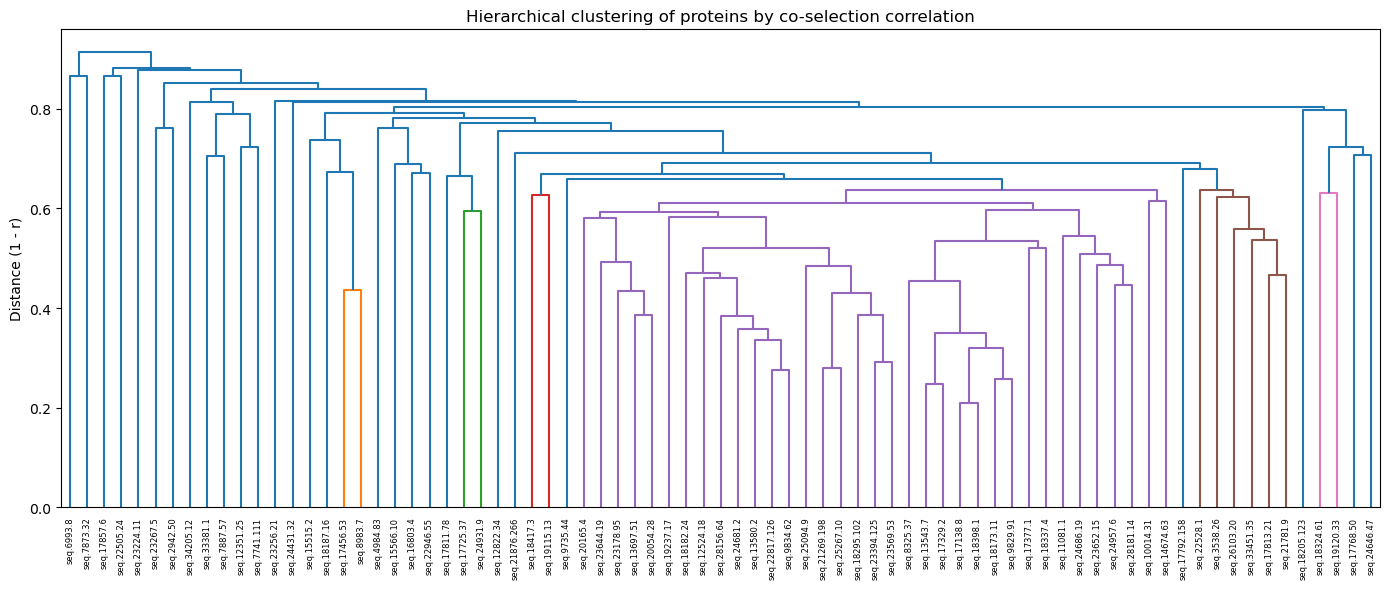

In [ ]:
# Convert co-selection correlation to distance
# Use 1 - r_ij for positive correlations; but r can be negative,
# so use 1 - r_ij which maps [-1,1] -> [2,0]
# Only among the kept proteins
dist_matrix = 1 - np.abs(r)  # high correlation -> small distance
np.fill_diagonal(dist_matrix, 0)

# Make sure it is symmetric and non-negative
dist_matrix = np.clip(dist_matrix, 0, None)
dist_matrix = (dist_matrix + dist_matrix.T) / 2

# Convert to condensed form for scipy
dist_condensed = squareform(dist_matrix, checks=False)

# Ward linkage requires Euclidean distances; use average linkage 
# for correlation-based distances
Z_hc = linkage(dist_condensed, method='average')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(
    Z_hc,
    labels=proteins_to_keep,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=None
)
plt.title("Hierarchical clustering of proteins by co-selection correlation")
plt.ylabel("Distance (1 - r)")
plt.tight_layout()
plt.show()

# Cut at a chosen number of clusters (match Leiden for comparison)
n_leiden_clusters = len(set(leiden_labels))
hc_labels = fcluster(Z_hc, t=n_leiden_clusters, criterion='maxclust')
hc_labels = hc_labels - 1  # zero-index to match Leiden

### Compare clusters

In [53]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(leiden_labels, hc_labels)
nmi = normalized_mutual_info_score(leiden_labels, hc_labels)
print(f"Leiden vs Hierarchical: ARI = {ari:.3f}, NMI = {nmi:.3f}")

Leiden vs Hierarchical: ARI = 0.024, NMI = 0.125


### Summarise clusters

In [54]:
cluster_df = pd.DataFrame({
    'protein': proteins_to_keep,
    'pi': pi,
    'leiden_cluster': leiden_labels,
    'hc_cluster': hc_labels
})

# Sort by cluster, then by selection frequency within cluster
cluster_df = cluster_df.sort_values(['leiden_cluster', 'pi'], ascending=[True, False])

for cl in sorted(cluster_df['leiden_cluster'].unique()):
    members = cluster_df[cluster_df['leiden_cluster'] == cl]
    print(f"\nCluster {cl}: {len(members)} proteins")
    print(f"  Top proteins: {members.head(5)['protein'].tolist()}")
    print(f"  pi range: [{members['pi'].min():.3f}, {members['pi'].max():.3f}]")


Cluster 0: 32 proteins
  Top proteins: ['seq.12524.18', 'seq.15566.10', 'seq.28156.64', 'seq.8983.7', 'seq.19115.13']
  pi range: [0.051, 0.100]

Cluster 1: 28 proteins
  Top proteins: ['seq.26103.20', 'seq.33451.35', 'seq.17813.21', 'seq.22528.1', 'seq.23224.11']
  pi range: [0.059, 0.247]

Cluster 2: 16 proteins
  Top proteins: ['seq.17725.37', 'seq.21781.9', 'seq.18324.61', 'seq.24931.9', 'seq.7887.57']
  pi range: [0.054, 0.145]

Cluster 3: 1 proteins
  Top proteins: ['seq.6993.8']
  pi range: [0.052, 0.052]


### Visulize

C:\Users\Love\AppData\Local\Temp\ipykernel_19032\1232372033.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', n_clusters)


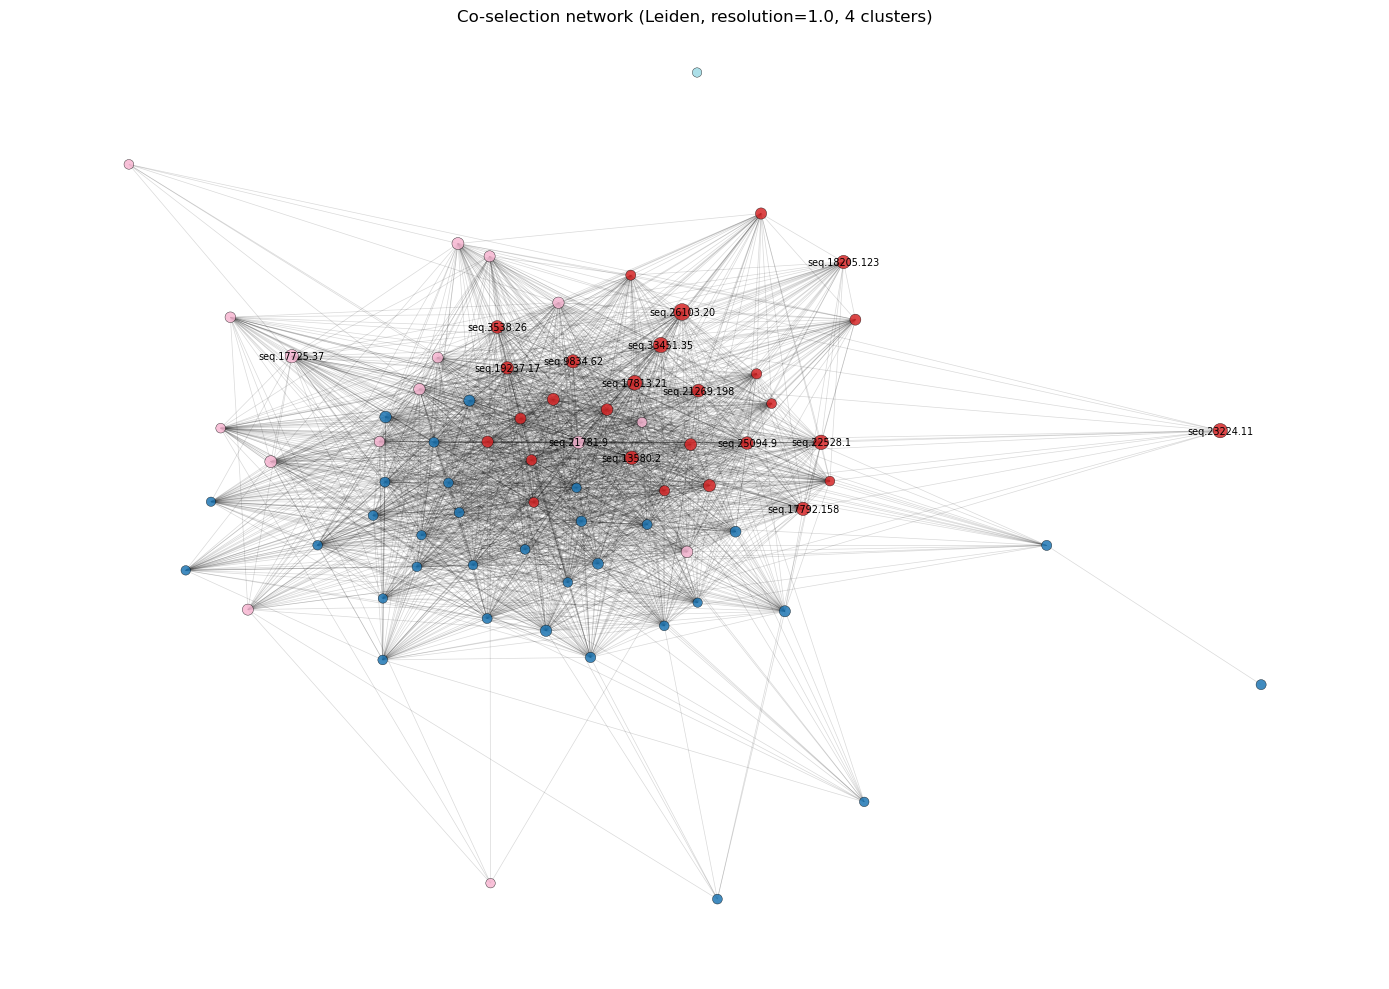

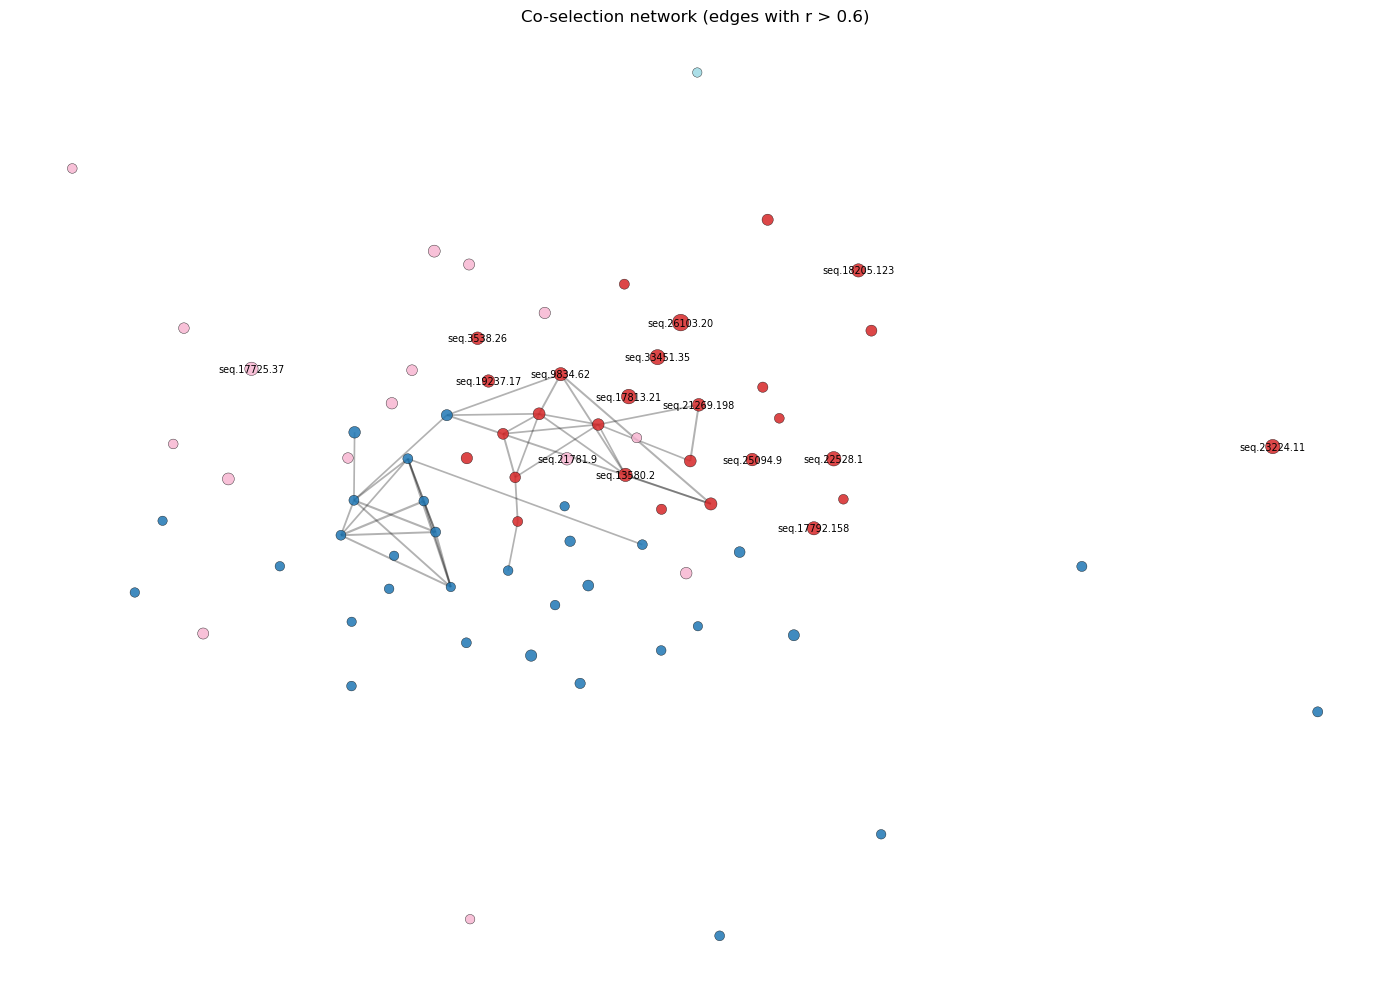

In [55]:
import networkx as nx
import matplotlib.cm as cm

# ── Build networkx graph from the same adjacency matrix ──
G = nx.Graph()
G.add_nodes_from(range(len(proteins_to_keep)))

sources, targets = np.where(np.triu(adj_positive, k=1) > 0)
weights = adj_positive[sources, targets]
for s, t, w in zip(sources, targets, weights):
    G.add_edge(s, t, weight=w)

# ── Node attributes ──
for i, prot in enumerate(proteins_to_keep):
    G.nodes[i]['name'] = prot
    G.nodes[i]['cluster'] = int(leiden_labels[i])
    G.nodes[i]['pi'] = float(pi[i])

# ── Layout ──
# spring layout: edge weights act as attraction
# k controls spacing; increase if graph is too dense
pos = nx.spring_layout(G, weight='weight', k=1.5, seed=42, iterations=100)

# ── Colors by cluster ──
n_clusters = len(set(leiden_labels))
cmap = cm.get_cmap('tab20', n_clusters)
node_colors = [cmap(leiden_labels[i]) for i in range(len(proteins_to_keep))]

# ── Node size proportional to selection frequency ──
node_sizes = pi * 500 + 20  # scale for visibility

# ── Draw ──
plt.figure(figsize=(14, 10))

# Edges (thin, light)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5)

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='black',
    linewidths=0.3,
    alpha=0.85
)

# Labels for top proteins only (to avoid clutter)
top_n_labels = 15  # label only the top-pi proteins
top_indices = np.argsort(pi)[-top_n_labels:]
labels = {i: proteins_to_keep[i] for i in top_indices}
nx.draw_networkx_labels(G, pos, labels, font_size=7)

plt.title(f"Co-selection network (Leiden, resolution={chosen_resolution}, "
          f"{n_clusters} clusters)")
plt.axis('off')
plt.tight_layout()
plt.show()

# ── Visualization threshold ──
vis_threshold = 0.6  # only show edges with r > this value

# Draw with filtered edges
plt.figure(figsize=(14, 10))

# Filter edges for visualization only (clustering still uses all edges above the 
# permutation threshold)
edges_to_draw = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= vis_threshold]
edge_weights_draw = [G[u][v]['weight'] for u, v in edges_to_draw]

# Optional: scale edge width/opacity by weight
edge_widths = [w * 2 for w in edge_weights_draw]  # adjust multiplier as needed

nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, alpha=0.3, 
                       width=edge_widths)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=0.3, alpha=0.85)

labels = {i: proteins_to_keep[i] for i in np.argsort(pi)[-top_n_labels:]}
nx.draw_networkx_labels(G, pos, labels, font_size=7)

plt.title(f"Co-selection network (edges with r > {vis_threshold})")
plt.axis('off')
plt.tight_layout()
plt.show()

## SomaLogic Annotation

In [ ]:
probeid = [seq_to_probeid(prot) for prot in proteins_to_keep]
protein_cluster_df = pd.DataFrame({
    "PROBEID": probeid,
    "protein": proteins_to_keep,
    "leiden_cluster": leiden_labels,
    "hc_cluster": hc_labels,
    "pi": pi
})
#protein_cluster_df.head()
protein_cluster_df = protein_cluster_df.merge(annot_df, on="PROBEID", how="left")
protein_cluster_df.head(10)

,PROBEID,protein,leiden_cluster,hc_cluster,pi,SYMBOL,UNIPROT,ENTREZID,GENENAME
0,10014-31,seq.10014.31,1,2,0.070,SNAI2,B2R6P6,6591.0,snail family transcriptional repressor 2
1,11081-1,seq.11081.1,0,2,0.053,GPD1,B2R6C0,2819.0,glycerol-3-phosphate dehydrogenase 1
2,12351-25,seq.12351.25,2,2,0.088,STAT1,A0A669KB56,6772.0,signal transducer and activator of transcripti...
3,12524-18,seq.12524.18,0,2,0.100,SAT2,Q502X4,112483.0,spermidine/spermine N1-acetyltransferase famil...
4,12822-34,seq.12822.34,1,2,0.065,APBB1,A0A075B7G8,322.0,amyloid beta precursor protein binding family ...
5,13543-7,seq.13543.7,0,2,0.064,PTGR1,A8K0N2,22949.0,prostaglandin reductase 1
6,13580-2,seq.13580.2,1,2,0.147,UAP1,A0A140VKC0,6675.0,UDP-N-acetylglucosamine pyrophosphorylase 1
7,13697-51,seq.13697.51,0,2,0.058,GPD1,B2R6C0,2819.0,glycerol-3-phosphate dehydrogenase 1
8,14674-63,seq.14674.63,0,2,0.056,PACSIN3,A0A0C4DGG1,29763.0,protein kinase C and casein kinase substrate i...
9,15515-2,seq.15515.2,0,2,0.055,SAA1,E9PQD6,6288.0,serum amyloid A1


In [64]:
# list of proteins in each leiden cluster
cl = 1
members = protein_cluster_df[protein_cluster_df['leiden_cluster'] == cl]
print(len(members))
for member in members.itertuples():
    #print(member.SYMBOL)
    print(f"{member.SYMBOL}, {member.pi}")

28
SNAI2, 0.07
APBB1, 0.065
UAP1, 0.147
HAO1, 0.091
ALDH5A1, 0.143
BPHL, 0.182
PCK1, 0.095
MAGEA6, 0.143
GRHPR, 0.102
DDT, 0.12
ACO1, 0.063
DPYS, 0.061
EPHX2, 0.128
PICK1, 0.059
PHF11, 0.178
TRIM9, 0.115
RGN, 0.174
GAS2, 0.079
STARD10, 0.085
TKFC, 0.069
AGXT, 0.086
PSPH, 0.109
ACSS2, 0.125
HSPA12A, 0.106
SDHAF2, 0.247
HSF4, 0.198
DDC, 0.127
ADH1B, 0.142


In [66]:
# List proteins top pi proteins
top_pi = protein_cluster_df[protein_cluster_df['pi'] > 0.08]
for prot in top_pi.itertuples():
    print(f"{prot.SYMBOL}, {prot.pi}")

STAT1, 0.088
SAT2, 0.1
UAP1, 0.147
CNN1, 0.095
USH1C, 0.145
HAO1, 0.091
ALDH5A1, 0.143
SULT1C2, 0.082
BPHL, 0.182
PCK1, 0.095
MAGEA6, 0.143
GRHPR, 0.102
SUOX, 0.109
CMBL, 0.084
DAO, 0.095
DDT, 0.12
EPHX2, 0.128
ACY3, 0.123
PHF11, 0.178
TRIM9, 0.115
RGN, 0.174
STARD10, 0.085
PIPOX, 0.081
AGXT, 0.086
PSPH, 0.109
EPS8L3, 0.108
ACSS2, 0.125
HSPA12A, 0.106
SDHAF2, 0.247
CYP1A2, 0.089
GSTA5, 0.097
NOTCH2NLB, 0.089
HSF4, 0.198
DDC, 0.127
COX5B, 0.1
GOLM1, 0.089
ADH1B, 0.142
